**Plant Village**

# VGG16 + Warm-up

Importando data (descomprimo en colab) y verificando que se carguen todas las imágenes

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [8]:
import os
print(os.listdir("/content/drive/MyDrive"))

['Colab Notebooks', 'PlantVillage.zip', 'vgg16_warmup_phase1.h5', 'vgg16_warmup_test_results.csv', 'history_phase1.csv', 'vgg16_warmup_phase1.keras', 'vgg16_warmup_final.keras', 'history_phase2.csv']


In [9]:
!unzip -q "/content/drive/MyDrive/PlantVillage.zip" -d "/content/plantdisease"

In [30]:
import os

print(os.listdir("/content/plantdisease"))

['plantvillage', 'PlantVillage']


In [31]:
import os

print("PlantVillage:")
print(os.listdir("/content/plantdisease/PlantVillage")[:10])

print("\nplantvillage:")
print(os.listdir("/content/plantdisease/plantvillage")[:10])

PlantVillage:
['Tomato_Bacterial_spot', 'Potato___Late_blight', 'Pepper__bell___Bacterial_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato_healthy', 'Pepper__bell___healthy', 'Potato___healthy', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Potato___Early_blight']

plantvillage:
['PlantVillage']


In [32]:
DATA_DIR = "/content/plantdisease/PlantVillage"

import os
print(len(os.listdir(DATA_DIR)))

15


In [33]:
import os

total = 0

for folder in os.listdir(DATA_DIR):
    folder_path = os.path.join(DATA_DIR, folder)

    if os.path.isdir(folder_path):
        num_images = len([
            file for file in os.listdir(folder_path)
            if file.lower().endswith((".jpg", ".jpeg", ".png"))
        ])
        total += num_images
        print(f"{folder}: {num_images} imágenes")

print("\nTotal imágenes:", total)

Tomato_Bacterial_spot: 2127 imágenes
Potato___Late_blight: 1000 imágenes
Pepper__bell___Bacterial_spot: 997 imágenes
Tomato_Spider_mites_Two_spotted_spider_mite: 1676 imágenes
Tomato_healthy: 1591 imágenes
Pepper__bell___healthy: 1478 imágenes
Potato___healthy: 152 imágenes
Tomato_Early_blight: 1000 imágenes
Tomato_Late_blight: 1909 imágenes
Potato___Early_blight: 1000 imágenes
Tomato_Septoria_leaf_spot: 1771 imágenes
Tomato__Tomato_mosaic_virus: 373 imágenes
Tomato__Target_Spot: 1404 imágenes
Tomato__Tomato_YellowLeaf__Curl_Virus: 3208 imágenes
Tomato_Leaf_Mold: 952 imágenes

Total imágenes: 20638


Transformando a binario

In [34]:
import pandas as pd
import os

image_paths = []
labels = []
class_names = []

for folder in os.listdir(DATA_DIR):
    folder_path = os.path.join(DATA_DIR, folder)

    if os.path.isdir(folder_path):
        #Reminder: 0 = sana, 1 = enfema
        label = 0 if "healthy" in folder.lower() else 1

        for file in os.listdir(folder_path):
            if file.lower().endswith((".jpg", ".jpeg", ".png")):
                image_paths.append(os.path.join(folder_path, file))
                labels.append(label)
                class_names.append(folder)

df = pd.DataFrame({
    "image_path": image_paths,
    "label": labels,
    "original_class": class_names
})

df.head()

,image_path,label,original_class
0,/content/plantdisease/PlantVillage/Tomato_Bact...,1,Tomato_Bacterial_spot
1,/content/plantdisease/PlantVillage/Tomato_Bact...,1,Tomato_Bacterial_spot
2,/content/plantdisease/PlantVillage/Tomato_Bact...,1,Tomato_Bacterial_spot
3,/content/plantdisease/PlantVillage/Tomato_Bact...,1,Tomato_Bacterial_spot
4,/content/plantdisease/PlantVillage/Tomato_Bact...,1,Tomato_Bacterial_spot


In [35]:
df["label"].value_counts()

,count
label,
1,17417
0,3221


In [36]:
df["label"].value_counts(normalize=True)

,proportion
label,
1,0.843929
0,0.156071


Separando datasets

In [37]:
from sklearn.model_selection import train_test_split

#test (15%)
train_df, test_df = train_test_split(
    df,
    test_size=0.15,
    stratify=df["label"],
    random_state=42
)

#validación (15% de lo que queda)
train_df, val_df = train_test_split(
    train_df,
    test_size=0.15,
    stratify=train_df["label"],
    random_state=42
)

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

Train: 14910
Validation: 2632
Test: 3096


In [38]:
print("Train:")
print(train_df["label"].value_counts(normalize=True))

print("\nValidation:")
print(val_df["label"].value_counts(normalize=True))

print("\nTest:")
print(test_df["label"].value_counts(normalize=True))

Train:
label
1    0.84393
0    0.15607
Name: proportion, dtype: float64

Validation:
label
1    0.843845
0    0.156155
Name: proportion, dtype: float64

Test:
label
1    0.843992
0    0.156008
Name: proportion, dtype: float64


VGG16

In [39]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

val_test_datagen = ImageDataGenerator(
    rescale=1./255
)

train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col="image_path",
    y_col="label",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="raw",
    shuffle=True
)

val_generator = val_test_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col="image_path",
    y_col="label",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="raw",
    shuffle=False
)

test_generator = val_test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col="image_path",
    y_col="label",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="raw",
    shuffle=False
)

Found 14910 validated image filenames.
Found 2632 validated image filenames.
Found 3096 validated image filenames.


In [40]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.array([0, 1])

class_weights_values = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=train_df["label"]
)

class_weights = {
    0: class_weights_values[0],
    1: class_weights_values[1]
}

print(class_weights)

{0: np.float64(3.203695745595187), 1: np.float64(0.5924660255900819)}


Crear fase 1

In [41]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam

#VGG16 preentrenado en ImageNet
base_model = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

#fase 1 warm-up: freeze VGG16
base_model.trainable = False

#para clasificación binaria
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.4),
    layers.Dense(1, activation="sigmoid")
])

model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,780,481 (56.38 MB)

 Trainable params: 65,793 (257.00 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

Entrenar fase 1

In [43]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    mode="min",
    restore_best_weights=True
)

history_phase1 = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=15,
    class_weight=class_weights,
    callbacks=[early_stop]
)

Epoch 1/15
466/466 ━━━━━━━━━━━━━━━━━━━━ 249s 531ms/step - accuracy: 0.7280 - loss: 0.5550 - precision: 0.9355 - recall: 0.7278 - val_accuracy: 0.8685 - val_loss: 0.4068 - val_precision: 0.9611 - val_recall: 0.8798
Epoch 2/15
466/466 ━━━━━━━━━━━━━━━━━━━━ 231s 495ms/step - accuracy: 0.8500 - loss: 0.3787 - precision: 0.9738 - recall: 0.8450 - val_accuracy: 0.8514 - val_loss: 0.3636 - val_precision: 0.9761 - val_recall: 0.8447
Epoch 3/15
466/466 ━━━━━━━━━━━━━━━━━━━━ 227s 487ms/step - accuracy: 0.8681 - loss: 0.3127 - precision: 0.9814 - recall: 0.8600 - val_accuracy: 0.9005 - val_loss: 0.2665 - val_precision: 0.9693 - val_recall: 0.9109
Epoch 4/15
466/466 ━━━━━━━━━━━━━━━━━━━━ 249s 534ms/step - accuracy: 0.8849 - loss: 0.2754 - precision: 0.9832 - recall: 0.8786 - val_accuracy: 0.9153 - val_loss: 0.2260 - val_precision: 0.9664 - val_recall: 0.9320
Epoch 5/15
466/466 ━━━━━━━━━━━━━━━━━━━━ 240s 514ms/step - accuracy: 0.8894 - loss: 0.2576 - precision: 0.9843 - recall: 0.8830 - val_accuracy: 0

In [44]:
model.save("/content/drive/MyDrive/vgg16_warmup_phase1.keras")

import pandas as pd

pd.DataFrame(history_phase1.history).to_csv(
    "/content/drive/MyDrive/history_phase1.csv",
    index=False
)

Fase 2

In [45]:
#Unfreeze VGG16 (hacerlo entrenable)
base_model.trainable = True

#Freeze (tpdo menos las últimas 4 capas convolucionales)
for layer in base_model.layers[:-4]:
    layer.trainable = False

for layer in base_model.layers[-4:]:
    layer.trainable = True

#Imprime capas entrenables
for layer in base_model.layers:
    print(layer.name, layer.trainable)

input_layer_2 False
block1_conv1 False
block1_conv2 False
block1_pool False
block2_conv1 False
block2_conv2 False
block2_pool False
block3_conv1 False
block3_conv2 False
block3_conv3 False
block3_pool False
block4_conv1 False
block4_conv2 False
block4_conv3 False
block4_pool False
block5_conv1 True
block5_conv2 True
block5_conv3 True
block5_pool True


In [46]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,780,481 (56.38 MB)

 Trainable params: 7,145,217 (27.26 MB)

 Non-trainable params: 7,635,264 (29.13 MB)

Entrenar fase 2

In [47]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    mode="min",
    restore_best_weights=True
)

history_phase2 = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=15,
    class_weight=class_weights,
    callbacks=[early_stop]
)

Epoch 1/15
466/466 ━━━━━━━━━━━━━━━━━━━━ 253s 529ms/step - accuracy: 0.9448 - loss: 0.1285 - precision: 0.9920 - recall: 0.9422 - val_accuracy: 0.9631 - val_loss: 0.1073 - val_precision: 0.9967 - val_recall: 0.9595
Epoch 2/15
466/466 ━━━━━━━━━━━━━━━━━━━━ 237s 508ms/step - accuracy: 0.9706 - loss: 0.0756 - precision: 0.9964 - recall: 0.9686 - val_accuracy: 0.9768 - val_loss: 0.0664 - val_precision: 0.9954 - val_recall: 0.9770
Epoch 3/15
466/466 ━━━━━━━━━━━━━━━━━━━━ 232s 497ms/step - accuracy: 0.9779 - loss: 0.0582 - precision: 0.9968 - recall: 0.9770 - val_accuracy: 0.9810 - val_loss: 0.0627 - val_precision: 0.9959 - val_recall: 0.9815
Epoch 4/15
466/466 ━━━━━━━━━━━━━━━━━━━━ 236s 505ms/step - accuracy: 0.9848 - loss: 0.0388 - precision: 0.9981 - recall: 0.9839 - val_accuracy: 0.9890 - val_loss: 0.0412 - val_precision: 0.9915 - val_recall: 0.9955
Epoch 5/15
466/466 ━━━━━━━━━━━━━━━━━━━━ 234s 501ms/step - accuracy: 0.9874 - loss: 0.0348 - precision: 0.9981 - recall: 0.9870 - val_accuracy: 0

In [49]:
model.save("/content/drive/MyDrive/vgg16_warmup_final_15epochs.keras")

import pandas as pd

pd.DataFrame(history_phase2.history).to_csv(
    "/content/drive/MyDrive/history_phase2.csv",
    index=False
)

In [6]:
#Cargando modelo final

from tensorflow.keras.models import load_model
model = load_model("/content/drive/MyDrive/vgg16_warmup_final_15epochs.keras")

import pandas as pd
history_phase2 = pd.read_csv("/content/drive/MyDrive/history_phase2.csv")
history_phase2.head()

,accuracy,loss,precision,recall,val_accuracy,val_loss,val_precision,val_recall
0,0.945003,0.132024,0.991477,0.942939,0.968085,0.094431,0.992623,0.969383
1,0.968947,0.077812,0.995908,0.967178,0.969605,0.098264,0.998139,0.965781
2,0.978068,0.057325,0.996919,0.977032,0.969985,0.094353,0.998603,0.965781
3,0.981355,0.045214,0.997574,0.980291,0.977964,0.075987,0.998617,0.975236
4,0.985379,0.036151,0.998307,0.984344,0.989742,0.042893,0.996380,0.991445


Probando en set de test

In [50]:
test_loss, test_accuracy, test_precision, test_recall = model.evaluate(test_generator)

print("Test loss:", test_loss)
print("Test accuracy:", test_accuracy)
print("Test precision:", test_precision)
print("Test recall:", test_recall)

97/97 ━━━━━━━━━━━━━━━━━━━━ 21s 220ms/step - accuracy: 0.9910 - loss: 0.0201 - precision: 0.9928 - recall: 0.9966
Test loss: 0.02011740207672119
Test accuracy: 0.9909560680389404
Test precision: 0.9927563667297363
Test recall: 0.9965556859970093


Matriz de confusión

97/97 ━━━━━━━━━━━━━━━━━━━━ 21s 214ms/step


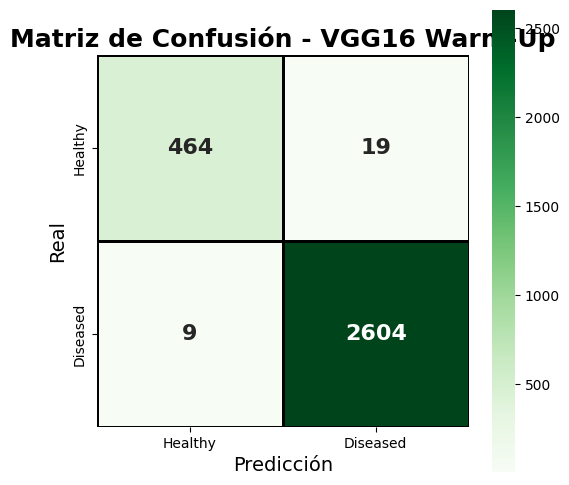

In [62]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Predicciones
test_generator.reset()

y_prob = model.predict(test_generator)
y_pred = (y_prob > 0.5).astype(int).ravel()

y_true = test_generator.labels

# Matriz de confusión
cm = confusion_matrix(y_true, y_pred)

# Plot
plt.figure(figsize=(6,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    cbar=True,
    xticklabels=["Healthy", "Diseased"],
    yticklabels=["Healthy", "Diseased"],
    annot_kws={"size":16, "weight":"bold"},
    linewidths=1,
    linecolor="black",
    square=True
)

plt.title("Matriz de Confusión - VGG16 Warm-Up", fontsize=18, weight="bold")
plt.xlabel("Predicción", fontsize=14)
plt.ylabel("Real", fontsize=14)

plt.show()

In [63]:
#FI

from sklearn.metrics import f1_score

f1 = f1_score(y_true, y_pred)

print("F1 Score:", f1)

F1 Score: 0.9946524064171123


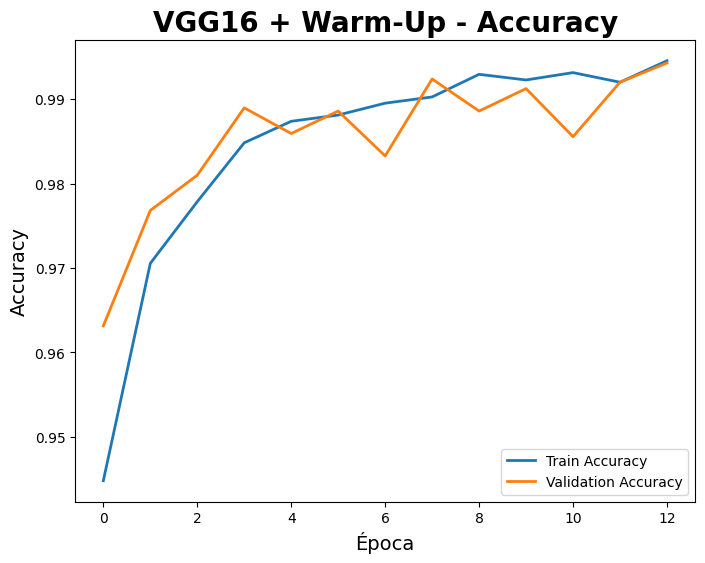

In [60]:
#Accuracy vs Epochs

import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.plot(
    history_phase2.history['accuracy'],
    label='Train Accuracy',
    linewidth=2
)

plt.plot(
    history_phase2.history['val_accuracy'],
    label='Validation Accuracy',
    linewidth=2
)

plt.title('VGG16 + Warm-Up - Accuracy', fontsize=20, weight='bold')
plt.xlabel('Época', fontsize=14)
plt.ylabel('Accuracy', fontsize=14)

plt.legend(loc='lower right')

plt.show()

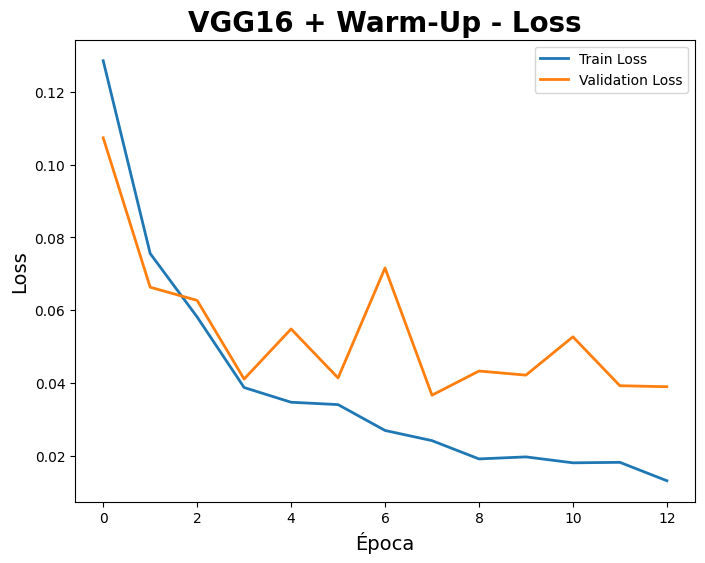

In [61]:
#Loss vs Epochs

plt.figure(figsize=(8,6))

plt.plot(
    history_phase2.history['loss'],
    label='Train Loss',
    linewidth=2
)

plt.plot(
    history_phase2.history['val_loss'],
    label='Validation Loss',
    linewidth=2
)

plt.title('VGG16 + Warm-Up - Loss', fontsize=20, weight='bold')
plt.xlabel('Época', fontsize=14)
plt.ylabel('Loss', fontsize=14)

plt.legend(loc='upper right')

plt.show()

Pruebas de éxito y error

In [75]:
import numpy as np
import pandas as pd

test_generator.reset()

y_prob = model.predict(test_generator).ravel()
y_pred = (y_prob > 0.5).astype(int)
y_true = test_generator.labels.astype(int)

#resultados
results_df = pd.DataFrame({
    "image_path": test_generator.filepaths,
    "y_true": y_true,
    "y_pred": y_pred,
    "prob_diseased": y_prob
})

label_map = {
    0: "Healthy",
    1: "Diseased"
}

results_df["real"] = results_df["y_true"].map(label_map)
results_df["prediccion"] = results_df["y_pred"].map(label_map)

results_df["tipo"] = np.where(
    results_df["y_true"] == results_df["y_pred"],
    "Éxito",
    np.where(
        (results_df["y_true"] == 1) & (results_df["y_pred"] == 0),
        "Falso negativo",
        "Falso positivo"
    )
)

results_df.head()

97/97 ━━━━━━━━━━━━━━━━━━━━ 20s 210ms/step


,image_path,y_true,y_pred,prob_diseased,real,prediccion,tipo
0,/content/plantdisease/PlantVillage/Tomato_Leaf...,1,1,0.999809,Diseased,Diseased,Éxito
1,/content/plantdisease/PlantVillage/Tomato_Leaf...,1,1,0.999999,Diseased,Diseased,Éxito
2,/content/plantdisease/PlantVillage/Potato___he...,0,0,0.004918,Healthy,Healthy,Éxito
3,/content/plantdisease/PlantVillage/Tomato__Tom...,1,1,1.000000,Diseased,Diseased,Éxito
4,/content/plantdisease/PlantVillage/Tomato_Sept...,1,1,0.999999,Diseased,Diseased,Éxito


In [77]:
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import load_img

def mostrar_ejemplos(df, tipo, n=6):
    ejemplos = df[df["tipo"] == tipo].sample(
        n=min(n, len(df[df["tipo"] == tipo])),
        random_state=42
    )

    plt.figure(figsize=(15, 8))

    for i, (_, row) in enumerate(ejemplos.iterrows()):
        img = load_img(row["image_path"], target_size=(224, 224))

        plt.subplot(2, 3, i + 1)
        plt.imshow(img)
        plt.axis("off")

        plt.title(
            f"{tipo}\nReal: {row['real']} | Pred: {row['prediccion']}\nProb enferma: {row['prob_diseased']:.2f}",
            fontsize=10
        )

    plt.tight_layout()
    plt.show()

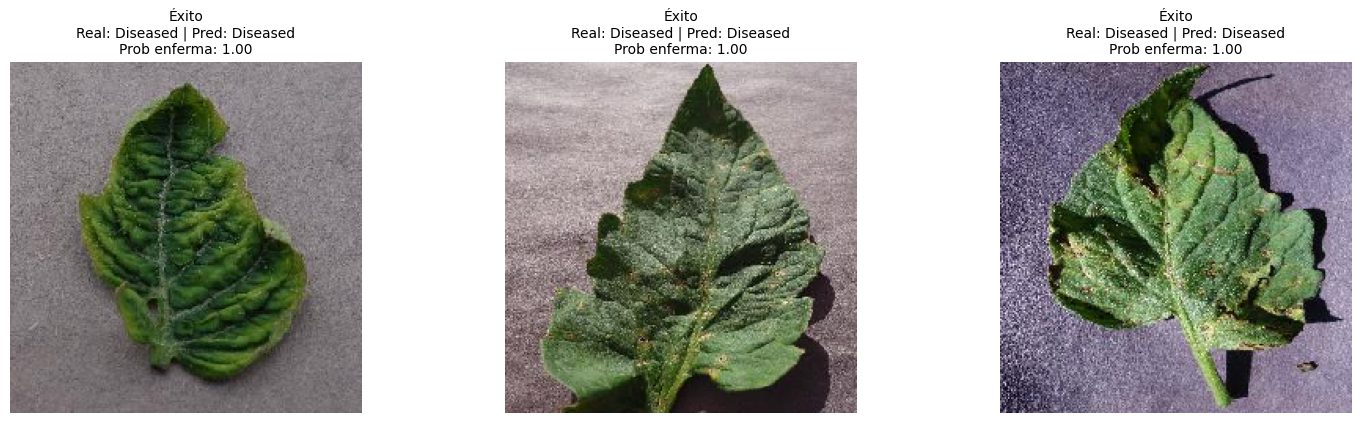

In [79]:
mostrar_ejemplos(results_df, "Éxito", n=3)

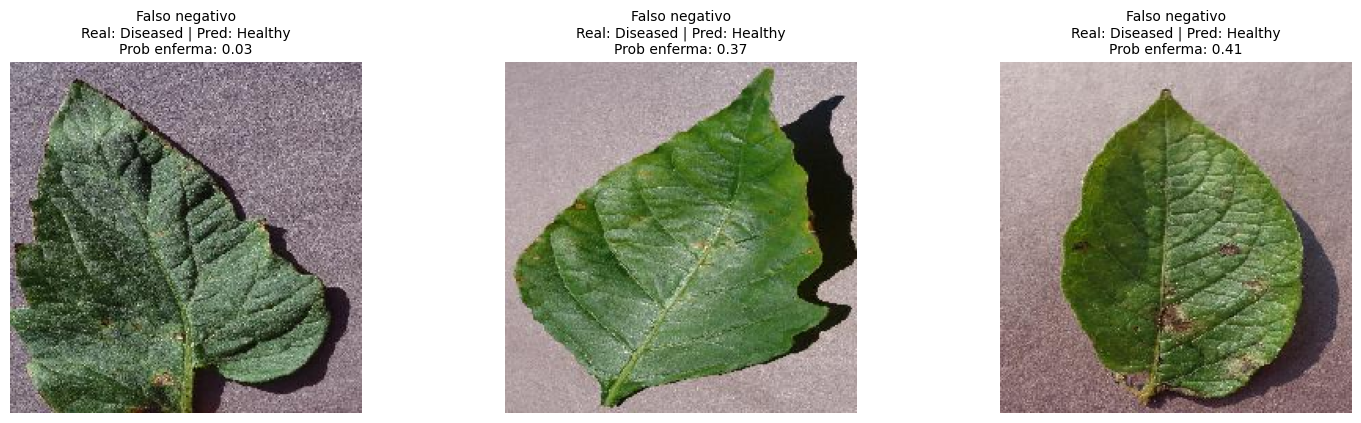

In [80]:
mostrar_ejemplos(results_df, "Falso negativo", n=3)

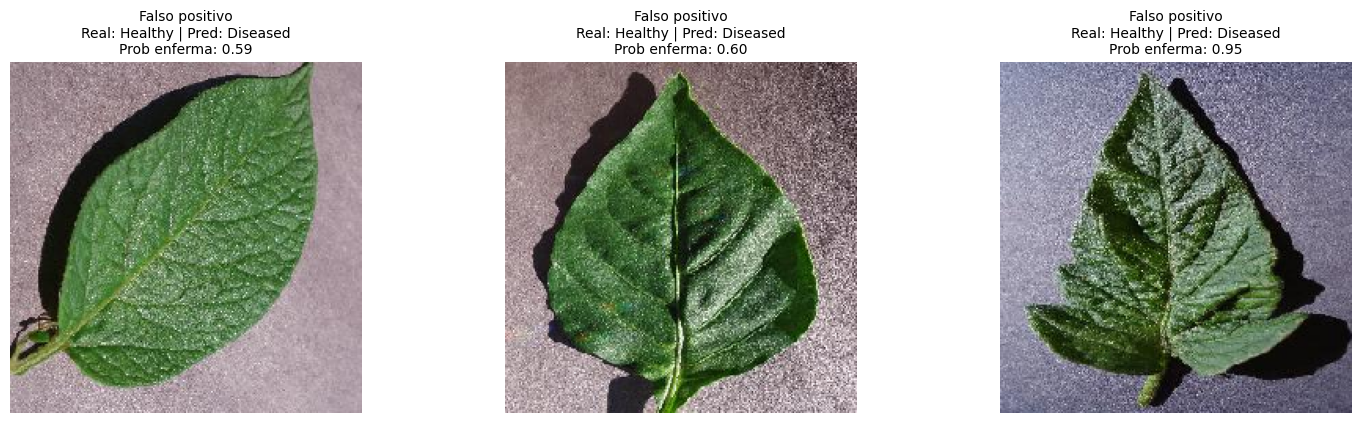

In [82]:
mostrar_ejemplos(results_df, "Falso positivo", n=3)

# DensNet121 + Fine Tuning

In [64]:
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import Precision, Recall
from tensorflow.keras.callbacks import EarlyStopping

base_densenet = DenseNet121(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

base_densenet.trainable = True

for layer in base_densenet.layers[:-40]:
    layer.trainable = False

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [65]:
model_densenet = models.Sequential([
    base_densenet,

    layers.GlobalAveragePooling2D(),

    layers.Dense(
        256,
        activation="relu",
        kernel_regularizer=regularizers.l2(0.001)
    ),

    layers.Dropout(0.5),

    layers.Dense(1, activation="sigmoid")
])

model_densenet.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,300,161 (27.85 MB)

 Trainable params: 1,090,369 (4.16 MB)

 Non-trainable params: 6,209,792 (23.69 MB)

In [66]:
model_densenet.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        Precision(name="precision"),
        Recall(name="recall")
    ]
)

In [67]:
early_stop_densenet = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

In [68]:
history_densenet = model_densenet.fit(
    train_generator,
    validation_data=val_generator,
    epochs=15,
    class_weight=class_weights,
    callbacks=[early_stop_densenet]
)

Epoch 1/15
466/466 ━━━━━━━━━━━━━━━━━━━━ 288s 527ms/step - accuracy: 0.7211 - loss: 0.9196 - precision: 0.9369 - recall: 0.7179 - val_accuracy: 0.8701 - val_loss: 0.7020 - val_precision: 0.9796 - val_recall: 0.8640
Epoch 2/15
466/466 ━━━━━━━━━━━━━━━━━━━━ 196s 421ms/step - accuracy: 0.8733 - loss: 0.6464 - precision: 0.9792 - recall: 0.8683 - val_accuracy: 0.9111 - val_loss: 0.5725 - val_precision: 0.9940 - val_recall: 0.9000
Epoch 3/15
466/466 ━━━━━━━━━━━━━━━━━━━━ 196s 421ms/step - accuracy: 0.9180 - loss: 0.5289 - precision: 0.9877 - recall: 0.9142 - val_accuracy: 0.9316 - val_loss: 0.4965 - val_precision: 0.9976 - val_recall: 0.9212
Epoch 4/15
466/466 ━━━━━━━━━━━━━━━━━━━━ 196s 421ms/step - accuracy: 0.9469 - loss: 0.4452 - precision: 0.9931 - recall: 0.9436 - val_accuracy: 0.9457 - val_loss: 0.4310 - val_precision: 0.9981 - val_recall: 0.9374
Epoch 5/15
466/466 ━━━━━━━━━━━━━━━━━━━━ 196s 420ms/step - accuracy: 0.9569 - loss: 0.4003 - precision: 0.9941 - recall: 0.9545 - val_accuracy: 0

In [69]:
model_densenet.save("/content/drive/MyDrive/densenet121_finetuning_final.keras")

import pandas as pd

pd.DataFrame(history_densenet.history).to_csv(
    "/content/drive/MyDrive/history_densenet.csv",
    index=False
)

In [70]:
test_results_densenet = model_densenet.evaluate(test_generator)

print("Test loss:", test_results_densenet[0])
print("Test accuracy:", test_results_densenet[1])
print("Test precision:", test_results_densenet[2])
print("Test recall:", test_results_densenet[3])

97/97 ━━━━━━━━━━━━━━━━━━━━ 22s 222ms/step - accuracy: 0.9822 - loss: 0.2218 - precision: 0.9996 - recall: 0.9793
Test loss: 0.22175556421279907
Test accuracy: 0.9822351336479187
Test precision: 0.9996093511581421
Test recall: 0.9793341159820557


Matríz de Confusión

97/97 ━━━━━━━━━━━━━━━━━━━━ 35s 220ms/step


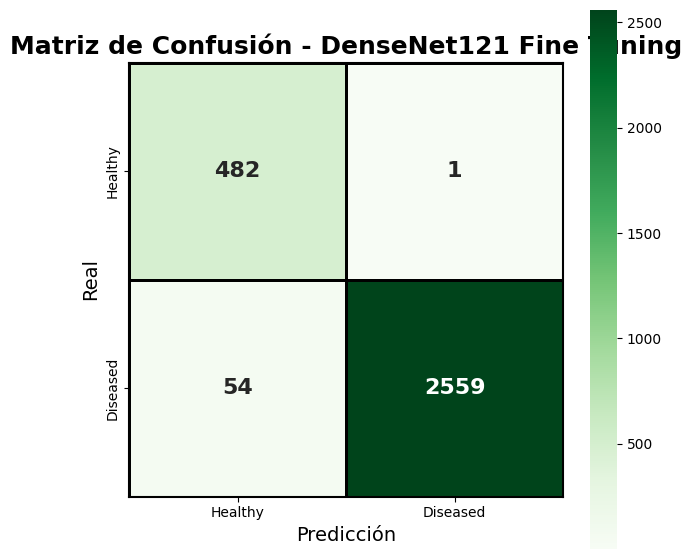

In [71]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Predicciones
test_generator.reset()

y_prob = model_densenet.predict(test_generator)
y_pred = (y_prob > 0.5).astype(int).ravel()

y_true = test_generator.labels

# Matriz de confusión
cm = confusion_matrix(y_true, y_pred)

# Plot
plt.figure(figsize=(7,7))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    cbar=True,
    xticklabels=["Healthy", "Diseased"],
    yticklabels=["Healthy", "Diseased"],
    annot_kws={"size":16, "weight":"bold"},
    linewidths=1,
    linecolor="black",
    square=True
)

plt.title("Matriz de Confusión - DenseNet121 Fine Tuning", fontsize=18, weight="bold")
plt.xlabel("Predicción", fontsize=14)
plt.ylabel("Real", fontsize=14)

ax = plt.gca()

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color("black")
    spine.set_linewidth(1.5)

plt.show()

In [72]:
from sklearn.metrics import f1_score

f1_densenet = f1_score(y_true, y_pred)

print("F1 Score DenseNet121:", f1_densenet)

F1 Score DenseNet121: 0.989367871641214


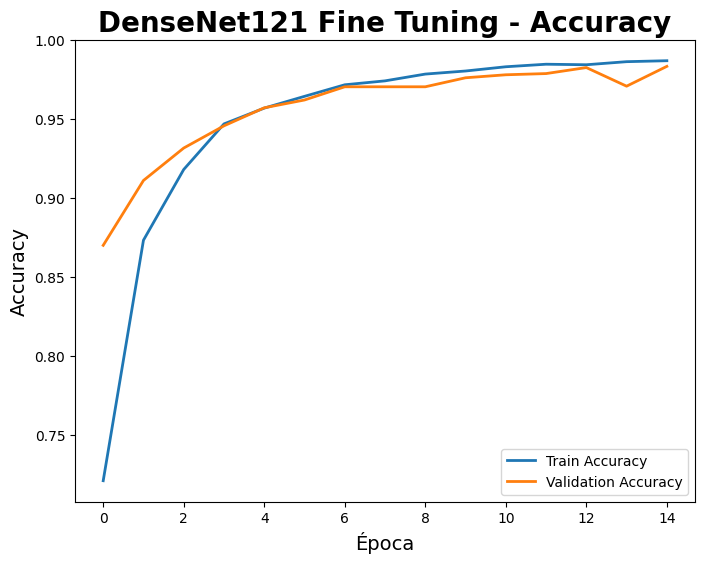

In [73]:
#Accuracy vs Epochs

import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.plot(
    history_densenet.history['accuracy'],
    label='Train Accuracy',
    linewidth=2
)

plt.plot(
    history_densenet.history['val_accuracy'],
    label='Validation Accuracy',
    linewidth=2
)

plt.title('DenseNet121 Fine Tuning - Accuracy', fontsize=20, weight='bold')
plt.xlabel('Época', fontsize=14)
plt.ylabel('Accuracy', fontsize=14)

plt.legend(loc='lower right')

plt.show()

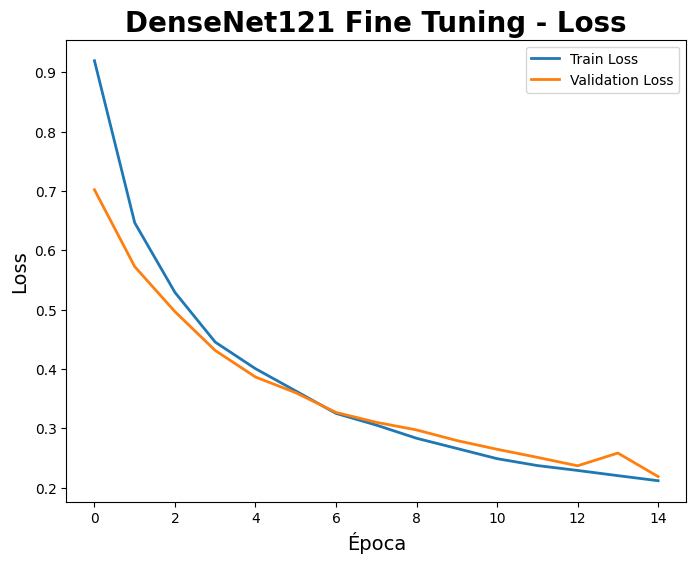

In [74]:
#Loss vs Epochs

plt.figure(figsize=(8,6))

plt.plot(
    history_densenet.history['loss'],
    label='Train Loss',
    linewidth=2
)

plt.plot(
    history_densenet.history['val_loss'],
    label='Validation Loss',
    linewidth=2
)

plt.title('DenseNet121 Fine Tuning - Loss', fontsize=20, weight='bold')
plt.xlabel('Época', fontsize=14)
plt.ylabel('Loss', fontsize=14)

plt.legend(loc='upper right')

plt.show()